---
numbering:
  enumerator: "11.%s"
  headings: true
  equation:
    template: "%s"
---
(chap_bayes)=
# Bayesian methods

This section is dedicated to the subset of machine learning that makes prior assumptions on parameters. Before we explain how Bayes' theorem can be applied to simple building blocks in machine learning, we introduce some notations and concepts in the subsection below. Good references for Bayesian analysis are @gelman2013bayesian and @kruschke2014doing. The latter, like the present book, illustrates the concepts with many lines of R code. Bayesian inference is used in @feng2021factor to estimate conditional expected returns and residual covariance matrices with a view to portfolio choice. 

## The Bayesian framework

Up to now, the models that have been presented rely on data only. This approach is often referred to as '**frequentist**'. Given one dataset, a frequentist will extract (i.e., estimate) a unique set of optimal parameters and consider it to be the best model. Bayesians, on the other hand, consider datasets as **snapshots of reality** and, for them, parameters are thus random! Instead of estimating one value for parameters (e.g., a coefficient in a linear model), they are more ambitious and try to determine the **whole distribution** of the parameter. 

In order to outline how that can be achieved, we introduce basic notations and results. The foundational concept in Bayesian analysis is the **conditional probability**. Given two random sets (or events) $A$ and $B$, we define the probability of $A$ knowing $B$ (equivalently, the odds of having $A$, conditionally on having $B$) as
$$P[A|B]=\frac{P[A \cap B]}{P[B]},$$
that is, the probability of the intersection between the two sets divided by the probability of $B$. Likewise, the probability that both events occur is equal to $P[A \cap B] = P[A]P[B|A]$. Given $n$ disjoint events $A_i$, $i=1,...n$ such that $\sum_{i=1}^nP(A_i)=1$, then for any event $B$, the law of total probabilities is (or implies)
$$P(B)=\sum_{i=1}^nP(B \cap A_i)= \sum_{i=1}^nP(B|A_i)P(A_i).$$

Given this expression, we can formulate a general version of Bayes' theorem:

$$
P(A_i|B)=\frac{P(A_i)P(B|A_i)}{P(B)}= \frac{P(A_i)P(B|A_i)}{\sum_{i=1}^nP(B|A_i)P(A_i)}.
$$ (eq:bayes)

Endowed with this result, we can move forward to the core topic of this section, which is the estimation of some parameter $\boldsymbol{\theta}$ (possibly a vector) given a dataset, which we denote with $\textbf{y}$ thereby following the conventions from @gelman2013bayesian. This notation is suboptimal in this book nonetheless because in all other chapters, $\textbf{y}$ stands for the label of a dataset.

In Bayesian analysis, one sophistication (compared to a frequentist approach) comes from the fact that the data is not almighty. The distribution of the parameter $\boldsymbol{\theta}$ will be a mix between some **prior** distribution set by the statistician (the user, the analyst) and the empirical distribution from the data. More precisely, a simple application of Bayes' formula yields

$$
p(\boldsymbol{\theta}| \textbf{y})=\frac{p(\boldsymbol{\theta})p(\textbf{y} |\boldsymbol{\theta})}{p(\textbf{y})} \propto p(\boldsymbol{\theta})p(\textbf{y} |\boldsymbol{\theta}).
$$ (eq:bayes2)

The interpretation is immediate: the distribution of $\boldsymbol{\theta}$ knowing the data $\textbf{y}$ is proportional to the distribution of $\boldsymbol{\theta}$ times the distribution of $\textbf{y}$ knowing $\boldsymbol{\theta}$. The term $p(\textbf{y})$ is often omitted because it is simply a scaling number that ensures that the density sums or integrates to one.

We use a slightly different notation between Equation {eq}`eq:bayes` and Equation {eq}`eq:bayes2`. In the former, $P$ denotes a true probability, i.e., it is a number. In the latter, $p$ stands for the whole probability density function of $\boldsymbol{\theta}$ or $\textbf{y}$.

The whole purpose of Bayesian analysis is to compute the so-called **posterior** distribution $p(\boldsymbol{\theta}| \textbf{y})$ via the **prior** distribution $p(\boldsymbol{\theta})$ and the **likelihood function** $p(\textbf{y} |\boldsymbol{\theta})$. Priors are sometimes qualified as informative, weakly informative or uninformative, depending on the degree to which the user is confident on the relevance and robustness of the prior. The simplest way to define a non-informative prior is to set a constant (uniform) distribution over some realistic interval(s). 

The most challenging part is usually the likelihood function. The easiest way to solve the problem is to resort to a specific distribution (possibly a parametric family) for the distribution of the data and then consider that obsevations are i.i.d., just as in a simple maximum likelihood inference. If we assume that new parameters for the distributions are gathered into $\boldsymbol{\lambda}$, then the likelihood can be written as 

$$
p(\textbf{y} |\boldsymbol{\theta}, \boldsymbol{\lambda})=\prod_{i=1}^I f_{\boldsymbol{\lambda}}(y_i; \boldsymbol{\beta}), 
$$ (eq:likelihood)
but in this case the problem becomes slightly more complex because adding new parameters changes the posterior distribution to $p(\boldsymbol{\theta}, \boldsymbol{\lambda}|\textbf{y})$. The user must find out the joint distribution of $\boldsymbol{\theta}$ and $\boldsymbol{\lambda}$ - given $\textbf{y}$. Because of their nested structure, these models are often called **hierarchical models**.

Bayesian methods are widely used for portfolio choice. The rationale is that the distribution of asset returns depends on some parameter and the main issue is to determine the posterior distribution. We very briefly review a vast literature below. Bayesian asset allocation is investigated in @lai2011mean (via stochastic optimization), @guidolin2016ambiguity and @dangl2020optimal. Shrinkage techniques (of means and covariance matrices) are tested in @frost1986empirical, @kan2007optimal and @demiguel2015parameter. In a similar vein, @tu2010incorporating build priors that are coherent with asset pricing theories. Finally, @bauder2020bayesian sample portfolio returns which allows to dervive a Bayesian optimal frontier. We invite the interested reader to also dwelve in the references that are cited within these few articles. 

## Bayesian sampling

### Gibbs sampling

One adjacent field of applications of Bayes' theorem is **simulation**. Suppose we want to simulate the multivariate distribution of a random vector $\textbf{X}$ given by its density $p=p(x_1,\dots,x_J)$. Often, the full distribution is complex, but its marginals are more accessible. Indeed, they are simpler because they depend on only one variable (when all other values are known): 
$$p(X_j=x_j|X_1= x_1,\dots,X_{j-1}=x_{j-1},X_{j+1}=x_{j+1},\dots,X_J=x_J)=p(X_j=x_j|\textbf{X}_{-j}=\textbf{x}_{-j}),$$ 
where we use the compact notation $\textbf{X}_{-j}$ for all variables except $X_j$. One way to generate samples with law $p$ is the following and relies both on the knowledge of the conditionals $p(x_j|\textbf{x}_{-j})$ and on the notion of **Markov Chain Monte Carlo**, which we outline below. The process is iterative and assumes that it is possible to draw samples of the aforementioned conditionals. We write $x_j^{m}$ for the $m^{th}$ sample of the $j^{th}$ variable ($X_j$). The simulation starts with a prior (or fixed, or random) sample $\textbf{x}^0=(x^0_1,\dots,x^0_J)$. Then, for a sufficiently large number of times, say $T$, new samples are drawn according to 
\begin{align*}
x_1^{m+1} &= p(X_1|X_2=x_2^{m}, \dots ,X_J=x_J^m) ;\\
x_2^{m+1} &=p(X_2|X_1=x_1^{m+1}, X_3=x^{m}_3, \dots, X_J=x_J^m); \\
\dots& \\
x_J^{m+1}&= p(X_J|X_1=x_1^{m+1}, X_2=x_2^{m+1}, \dots, X_{J-1}=x_{J-1}^{m+1}).
\end{align*}

The important detail is that after each line, the value of the variable is updated. Hence, in the second line, $X_2$ is sampled with the knowledge of $X_1=x_1^{m+1}$ and in the last line, all variables except $X_J$ have been updated to their $(m+1)^{th}$ state. The above algorithm is called Gibbs sampling. It relates to Markov chains because each new iteration depends only on the previous one. 

Under some technical assumptions, as $T$ increases, the distribution of $\textbf{x}_T$ converges to that of $p$. The conditions under which the convergence occurs have been widely discussed in series of articles in the 1990s. The interested reader can have a look for instance at @tierney1994markov, @roberts1994simple, as well as at section 11.7 of @gelman2013bayesian.

Sometimes, the full distribution is complex and the conditional laws are hard to determine and to sample. Then, a more general method, called Metropolis-Hastings, can be used that relies on the rejection method for the simulation of random variables.  

### Metropolis-Hastings sampling

The Gibbs algorithm can be considered as a particular case of the Metropolis-Hastings (MH) method, which, in its simplest version, was introduced in @metropolis1949monte. The premise is similar: the aim is to simulate random variables that follow $p(\textbf{x})$ with the ability to sample from a simpler form $p(\textbf{x}|\textbf{y})$ which gives the probability of the future state $\textbf{x}$, given the past one $\textbf{y}$. 

Once an initial value for $\textbf{x}$ has been sampled ($\textbf{x}_0$), each new iteration ($m$) of the simulation takes place in three stages:  

1. generate a candidate value $\textbf{x}'_{m+1}$ from $p(\textbf{x}|\textbf{x}_m)$,  
2. compute the acceptance ratio $\alpha=\min\left(\frac{p(\textbf{x}'_{m+1})p(\textbf{x}_{m}|\textbf{x}'_{m+1})}{p(\textbf{x}_{m})p(\textbf{x}'_{m+1}|\textbf{x}_{m})} \right)$     
3. pick $\textbf{x}_{m+1}=\textbf{x}'_{m+1}$ with probability $\alpha$ or stick with the previous value ($\textbf{x}_{m+1}=\textbf{x}_{m}$) with probability $1-\alpha$.   

The interpretation of the acceptance ratio is not straightforward in the general case. When the sampling generator is symmetric ($p(\textbf{x}|\textbf{y})=p(\textbf{y}|\textbf{x})$), the candidate is always chosen whenever $p(\textbf{x}'_{m+1})\ge p(\textbf{x}_{m})$. If the reverse condition holds ($p(\textbf{x}'_{m+1})< p(\textbf{x}_{m})$), then the candidate is retained with odds equal to $p(\textbf{x}'_{m+1})/p(\textbf{x}_{m})$, which is the ratio of likelihoods. The more likely the new proposal, the higher the odds of retaining it.    

Often, the first simulations are discarded in order to leave time to the chain to converge to a high probability region. This procedure (often called '*burn in*') ensures that the first retained samples are located in a zone that is likely, i.e., that they are more representative of the law we are trying to simulate.

For the sake of brevity, we stick to a succinct presentation here, but some additional details are outlined in section 11.2 of @gelman2013bayesian and in chapter 7 of @kruschke2014doing. 

## Bayesian linear regression

Because Bayesian concepts are rather abstract, it is useful to illustrate the theoretical notions with a simple example. In a linear model, $y_i=\textbf{x}_i\textbf{b}+\epsilon_i$ and it is often statistically assumed that the $\epsilon_i$ are i.i.d. and normally distributed with zero mean and variance $\sigma^2$. Hence, the likelihood of Equation {eq}`eq:likelihood` translates into
$$p(\boldsymbol{\epsilon}|\textbf{b}, \sigma)=\prod_{i=1}^I\frac{e^{-\frac{\epsilon_i^2}{2\sigma}}}{\sigma\sqrt{2\pi}}=(\sigma\sqrt{2\pi})^{-I}e^{-\sum_{i=1}^I\frac{\epsilon_i^2}{2\sigma^2}}.$$

In a regression analysis, the data is given both by $\textbf{y}$ and by $\textbf{X}$, hence both are reported in the notations. Simply acknowledging that $\boldsymbol{\epsilon}=\textbf{y}-\textbf{Xb}$, we get
\begin{align}
p(\textbf{y},\textbf{X}|\textbf{b}, \sigma)&=\prod_{i=1}^I\frac{e^{-\frac{\epsilon_i^2}{2\sigma}}}{\sigma\sqrt{2\pi}}\\
&=(\sigma\sqrt{2\pi})^{-I}e^{-\sum_{i=1}^I\frac{\left(y_i-\textbf{x}_i'\textbf{b}\right)^2}{2\sigma^2}}=(\sigma\sqrt{2\pi})^{-I} e^{-\frac{\left(\textbf{y}-\textbf{X}\textbf{b}\right)' \left(\textbf{y}-\textbf{X}\textbf{b}\right)}{2\sigma^2}} \\
&=\underbrace{(\sigma\sqrt{2\pi})^{-I} e^{-\frac{\left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)' \left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)}{2\sigma^2}}}_{\text{depends on } \sigma, \text{ not } \textbf{b}}\times \underbrace{e^{-\frac{(\textbf{b}-\hat{\textbf{b}})'\textbf{X}'\textbf{X}(\textbf{b}-\hat{\textbf{b}})}{2\sigma^2}}}_{\text{ depends on both } \sigma, \text{ and } \textbf{b} }.
\end{align} (eq:linlike)
In the last line, the second term is a function of the difference $\textbf{b}-\hat{\textbf{b}}$, where $\hat{\textbf{b}}=(\textbf{X}'\textbf{X})^{-1}\textbf{X}'\textbf{y}$. This is not surprising: $\hat{\textbf{b}}$ is a natural benchmark for the mean of $\textbf{b}$. Moreover, introducing $\hat{\textbf{b}}$ yields a relatively simple form for the probability.    

The above expression is the frequentist (data-based) block of the posterior: the likelihood. If we want to obtain a tractable expression for the posterior, we need to find a prior component that has a form that will combine well with this likelihood. These forms are called **conjugate priors**. A natural candidate for the right part (that depends on both **b** and $\sigma$) is the multivariate Gaussian density:

$$
p[\textbf{b}|\sigma]=\sigma^{-k}e^{-\frac{(\textbf{b}-\textbf{b}_0)'\boldsymbol{\Lambda}_0(\textbf{b}-\textbf{b}_0)}{2\sigma^2}},
$$ (eq:linprior)
where we are obliged to condition with respect to $\sigma$. The density has prior mean $\textbf{b}_0$ and prior covariance matrix $\boldsymbol{\Lambda}_0^{-1}$. This prior gets us one step closer to the posterior because
\begin{align}
p[\textbf{b},\sigma|\textbf{y},\textbf{X}]& \propto p[\textbf{y},\textbf{X}|\textbf{b},\sigma]p[\textbf{b},\sigma] \\
&\propto p[\textbf{y},\textbf{X}|\textbf{b},\sigma]p[\textbf{b}|\sigma]p[\sigma]. 
\end{align} (eq:cascade)

In order to fully specify the cascade of probabilities, we need to take care of $\sigma$ and set a density of the form

$$
p[\sigma^2]\propto (\sigma^2)^{-1-a_0}e^{-\frac{b_0}{2\sigma^2}},
$$ (eq:linsig)
which is close to that of the left part of {eq}`eq:linlike`. This corresponds to an inverse gamma distribution for the variance with prior parameters $a_0$ and $b_0$ (this scalar notation is not optimal because it can be confused with the prior mean $\textbf{b}_0$ so we must pay extra attention).

Now, we can simplify $p[\textbf{b},\sigma|\textbf{y},\textbf{X}]$ with {eq}`eq:linlike`, {eq}`eq:linprior` and {eq}`eq:linsig`:
\begin{align*}
p[\textbf{b},\sigma|\textbf{y},\textbf{X}]& \propto 
(\sigma\sqrt{2\pi})^{-I} \sigma^{-2(1+a_0)} e^{-\frac{\left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)' \left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)}{2\sigma^2}} \\
&\quad \times e^{-\frac{(\textbf{b}-\hat{\textbf{b}})'\textbf{X}'\textbf{X}(\textbf{b}-\hat{\textbf{b}})}{2\sigma^2}}\sigma^{-k}e^{-\frac{(\textbf{b}-\textbf{b}_0)'\boldsymbol{\Lambda}_0(\textbf{b}-\textbf{b}_0)}{2\sigma^2}}e^{-\frac{b_0}{2\sigma^2}} \\
\end{align*}
which can be rewritten 
\begin{align*}
p[\textbf{b},\sigma|\textbf{y},\textbf{X}]& \propto  \sigma^{-I-k-2(1+a_0)} \\
&\times  \exp\left(-\frac{\left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)' \left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right) + (\textbf{b}-\hat{\textbf{b}})'\textbf{X}'\textbf{X}(\textbf{b}-\hat{\textbf{b}}) + (\textbf{b}-\textbf{b}_0)'\boldsymbol{\Lambda}_0(\textbf{b}-\textbf{b}_0)+b_0}{2\sigma^2} \right) .
\end{align*}

The above expression is simply a quadratic form in $\textbf{b}$ and it can be rewritten after burdensome algebra in a much more compact manner:

$$
p(\textbf{b}|\textbf{y},\textbf{X},\sigma) \propto \left[\sigma^{-k}e^{-\frac{(\textbf{b}-\textbf{b}_*)'\boldsymbol{\Lambda}_*(\textbf{b}-\textbf{b}_*)}{2\sigma^2}}\right] \times \left[ (\sigma^2)^{-1-a_*}e^{-\frac{b_*}{2\sigma^2}}  \right],
$$ (eq:linpost)


where 
\begin{align*}
\boldsymbol{\Lambda}_* &= \textbf{X}'\textbf{X}+\boldsymbol{\Lambda}_0  \\
\textbf{b}_*&=  \boldsymbol{\Lambda}_*^{-1}(\boldsymbol{\Lambda}_0\textbf{b}_0+\textbf{X}'\textbf{X}\hat{\textbf{b}}) \\
a_* & = a_0 + I/2  \\
b_* &=b_0+\frac{1}{2}\left(\textbf{y}'\textbf{y}+ \textbf{b}_0'\boldsymbol{\Lambda}_0\textbf{b}_0+\textbf{b}_*'\boldsymbol{\Lambda}_*\textbf{b}_* \right).\\
\end{align*}

This expression has two parts: the Gaussian component which relates mostly to $\textbf{b}$, and the inverse gamma component, entirely dedicated to $\sigma$. The mix between the prior and the data is clear. The posterior covariance matrix of the Gaussian part ($\boldsymbol{\Lambda}_*$) is the sum between the prior and a quadratic form from the data. The posterior mean $\textbf{b}_*$ is a weighted average of the prior $\textbf{b}_0$ and the sample estimator $\hat{\textbf{b}}$. Such blends of quantities estimated from data and a user-supplied version are often called **shrinkages**. For instance, the original matrix of cross-terms $\textbf{X}'\textbf{X}$ is shrunk towards the prior $\boldsymbol{\Lambda}_0$. This can be viewed as a **regularization** procedure: the pure fit originating from the data is mixed with some 'external' ingredient to give some structure to the final estimation.

The interested reader can also have a look at section 16.3 of @greene2018econometric (the case of conjugate priors is treated in subsection 16.3.2).

The formulae above can be long and risky to implement. Luckily, there are Python packages that perform Bayesian inference for linear regression using conjugate priors. Below, we provide one example of how it works using PyMC. To simplify the code and curtail computation times, we consider two predictors: market capitalization (size anomaly) and price-to-book ratio (value anomaly). In statistics, the **precision matrix** is the inverse of the covariance matrix. In the parameters, the first two priors relate to the Gaussian law and the last two to the inverse gamma distribution: 
$$f_\text{invgamma}(x, \alpha, \beta)=\frac{\beta^\alpha}{\Gamma(\alpha)}x^{-1-\alpha}e^{-\frac{\beta}{x}},$$
where $\alpha$ is the shape and $\beta$ is the scale.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
from sklearn.svm import SVR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
import pymc as pm
import arviz as az

# Building the data & import functions
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()
features_short =["Div_yld", "EPS", "size_avg_252d", "mom_252", "OCF_Growth_1Y", "PB", "vol_252"]
separation_date = "2017-01-15"

data_ml_clean = data_ml.dropna(subset=(features_short + ['R1M']))
training_sample = data_ml_clean[data_ml['date'] <= separation_date]
testing_sample = data_ml_clean[data_ml['date'] > separation_date]  # 

In [2]:
# Define prior parameters
prior_mean = np.array([0.01, 0.1, 0.1])  # Average value of parameters (prior)
prior_cov = np.diag(prior_mean**2)       # Covariance matrix of parameters (prior)

# Prepare data for Bayesian regression: size (Mkt_Cap_3M_Usd) and value (Pb)
X_train = testing_sample[['size_avg_252d', 'PB']].values
y_train = testing_sample['R1M'].values

# Build Bayesian linear model with PyMC
with pm.Model() as bayesian_lm:
    # Priors for regression coefficients (intercept + 2 predictors)
    beta = pm.MvNormal('beta', mu=prior_mean, cov=prior_cov, shape=3)
    
    # Prior for noise variance (inverse gamma)
    sigma = pm.InverseGamma('sigma', alpha=0.5, beta=0.5)
    
    # Expected value of outcome
    mu = beta[0] + beta[1] * X_train[:, 0] + beta[2] * X_train[:, 1]
    
    # Likelihood (sampling distribution) of observations
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train)
    
    # Sample from posterior
    trace = pm.sample(2000, return_inferencedata=True, progressbar=True)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 43 seconds.


In the above specification, we must also provide a prior for the constant. By default, we set its average value to 0.01, which corresponds to a 1% average monthly return. Once the model has been estimated, we can plot the distribution of coefficient estimates.

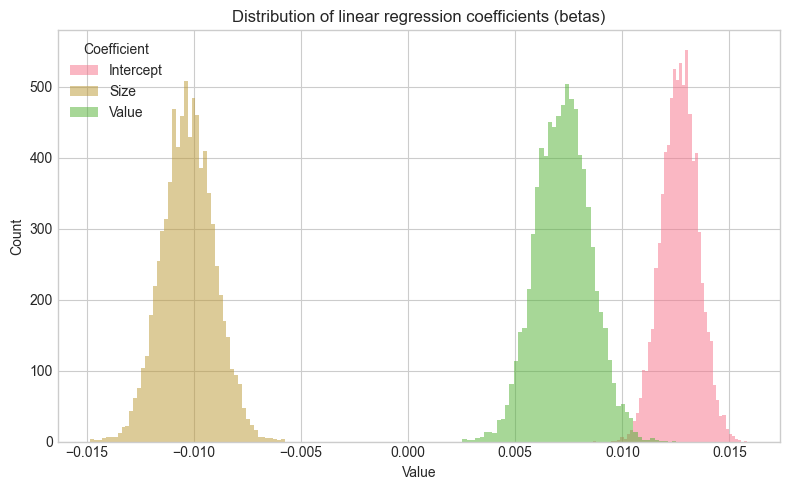

In [3]:
# Extract posterior samples for beta coefficients
beta_samples = trace.posterior['beta'].values.reshape(-1, 3)

# Create DataFrame for plotting
beta_df = pd.DataFrame(beta_samples, columns=['Intercept', 'Size', 'Value'])
beta_melted = beta_df.melt(var_name='coefficient', value_name='value')

# Plot distribution of linear regression coefficients (betas)
fig, ax = plt.subplots(figsize=(8, 5))
for coef in ['Intercept', 'Size', 'Value']:
    data = beta_df[coef]
    ax.hist(data, bins=50, alpha=0.5, label=coef)
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.legend(title='Coefficient')
ax.set_title('Distribution of linear regression coefficients (betas)')
plt.tight_layout()
plt.show()

The distribution of the constant in the figure is firmly to the right with a small dispersion, hence it is solidly positive. For the size coefficient, it is the opposite; it is negative (small firms are more profitable). With regard to value, it is hard to conclude, the distribution is balanced around zero: there is no clear exposition to the price-to-book ratio variable.

## Naive Bayes classifier

Bayes' theorem can also be easily applied to **classification**. We formulate it with respect to the label and features and write

$$
P[\textbf{y} | \textbf{X}] = \frac{P[ \textbf{X} | \textbf{y}]P[\textbf{y}]}{P[\textbf{X}]} \propto P[ \textbf{X} | \textbf{y}]P[\textbf{y}],
$$ (eq:naivebayes)
and then split the input matrix into its column vectors $\textbf{X}=(\textbf{x}_1,\dots,\textbf{x}_K)$. This yields

$$
P[\textbf{y} | \textbf{x}_1,\dots,\textbf{x}_K] \propto P[\textbf{x}_1,\dots,\textbf{x}_K| \textbf{y}]P[\textbf{y}].
$$ (eq:naivebayes2)

The 'naive' qualification of the method comes from a simplifying assumption on the features.[^10-fn1] If they are all mutually independent, then the likelihood in the above expression can be expanded into

$$
P[\textbf{y} | \textbf{x}_1,\dots,\textbf{x}_K] \propto P[\textbf{y}]\prod_{k=1}^K P[\textbf{x}_k| \textbf{y}].
$$ (eq:naivebayes3)

The next step is to be more specific about the likelihood. This can be done non-parametrically (via kernel estimation) or with common distributions (Gaussian for continuous data, Bernoulli for binary data). In factor investing, the features are continuous, thus the Gaussian law is more adequate:
$$P[x_{i,k}=z|\textbf{y}_i= c]=\frac{e^{-\frac{(z-m_c)^2}{2\sigma_c^2}}}{\sigma_c\sqrt{2\pi}},$$
where $c$ is the value of the classes taken by $y$ and $\sigma_c$ and $m_c$ are the standard error and mean of $x_{i,k}$, conditional on $y_i$ being equal to $c$. In practice, each class is spanned, the training set is filtered accordingly and $\sigma_c$ and $m_c$ are taken to be the sample statistics. This Gaussian parametrization is probably ill-suited to our dataset because the features are uniformly distributed. Even after conditioning, it is unlikely that the distribution will be even remotely close to Gaussian. Technically, this can be overcome via a double transformation method. Given a vector of features $\textbf{x}_k$ with empirical cdf $F_{\textbf{x}_k}$, the variable

$$
\tilde{\textbf{x}}_k=\Phi^{-1}\left(F_{\textbf{x}_k}(\textbf{x}_k) \right),
$$ (eq:transf)
will have a standard normal law whenever $F_{\textbf{x}_k}$ is not pathological. Non-pathological cases are when the cdf is continuous and strictly increasing and when observations lie in the open interval (0,1). If all features are independent, the transformation should not have any impact on the correlation structure. Otherwise, we refer to the literature on the NORmal-To-Anything (NORTA) method (see, e.g., @chen2001initialization and @coqueret2017approximate).


Lastly, the prior $P[\textbf{y}]$ in Equation {eq}`eq:naivebayes3` is often either taken to be uniform across the classes ($1/K$ for all $k$) or equal to the sample distribution. 

We illustrate the naive Bayes classification tool with a simple example. While the scikit-learn library embeds such a classifier (GaussianNB), we show how to use it below. Since the features are uniformly distributed, the transformation in {eq}`eq:transf` amounts to applying the Gaussian quantile function (inverse cdf).

For visual clarity, we only use the small set of features.

[^10-fn1]: This assumption can be relaxed, but the algorithms then become more complex and are out of the scope of the current book. One such example that generalizes the naive Bayes approach is @friedman1997bayesian.


In [4]:
from sklearn.naive_bayes import GaussianNB

# Prepare training features (without transformation)
X_train_NB = training_sample[features_short].values
y_train_NB = training_sample['R1M_C'].values

# Fit basic Naive Bayes classifier
fit_NB_basic = GaussianNB()
fit_NB_basic.fit(X_train_NB, y_train_NB)

# Display model parameters
print(f"Naive Bayes model fitted with {len(features_short)} features")
print(f"Training samples: {len(training_sample)}")
print(f"Class prior probabilities: {fit_NB_basic.class_prior_}")

Naive Bayes model fitted with 7 features
Training samples: 228548
Class prior probabilities: [0.50026253 0.49973747]


In [5]:
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Transform features using inverse Gaussian CDF (for uniformly distributed features)
def transform_features(data, features):
    """Apply Gaussian quantile transformation to features."""
    X = data[features].values
    X_clipped = np.clip(X, 0.0001, 0.9999)
    X_transformed = norm.ppf(X_clipped)
    return X_transformed

# Transform training features
gauss_features_train = transform_features(training_sample, features_short)

# Fit Naive Bayes classifier
fit_NB_gauss = GaussianNB()
fit_NB_gauss.fit(gauss_features_train, training_sample['R1M_C'])

print(f"Naive Bayes model fitted with {len(features_short)} features")
print(f"Training samples: {len(training_sample)}")

Naive Bayes model fitted with 7 features
Training samples: 228548


The plots show the distributions of the features, conditionally on each value of the label. Essentially, those are the densities $P[\textbf{x}_k| \textbf{y}]$. For each feature, both distributions are very similar. 

As usual, once the model has been trained, the accuracy of predictions can be evaluated.

In [6]:
# Transform test features
gauss_features_test = transform_features(testing_sample, features_short)

# Compute hit ratio
predictions = fit_NB_gauss.predict(gauss_features_test)
hit_ratio = np.mean(predictions == testing_sample['R1M_C'])
print(f"Hit ratio: {hit_ratio:.4f}")

Hit ratio: 0.5031


The performance of the classifier is not satisfactory as it underperforms a random guess. 

(BART)=
## Bayesian additive trees

### General formulation

Bayesian additive regression trees (BARTs) are an ensemble technique that mixes Bayesian thinking and regression trees. In spirit, they are close to the tree ensembles seen in Chapter {ref}`chap_trees`, but they differ greatly in their implementation. In BARTs like in Bayesian regressions, the regularization comes from the prior. The original article is @chipman2010bart and the implementation (in R) follows @sparapani2019r. BARTs have been used in @shu2021identifying to identify which characteristics are priced. The authors report that stocks' market capitalization is the only one that matters.

Formally, the model is an aggregation of $M$ models, which we write as

$$
y = \sum_{m=1}^M\mathcal{T}_m(q_m,\textbf{w}_m, \textbf{x}) + \epsilon,
$$ (eq:BART)
where $\epsilon$ is a Gaussian noise with variance $\sigma^2$, and the $\mathcal{T}_m=\mathcal{T}_m(q_m,\textbf{w}_m, \textbf{x})$ are decision trees with structure $q_m$ and weights vectors $\textbf{w}_m$. This decomposition of the tree is the one we used for boosted trees and is illustrated in the chapter on trees. $q_m$ codes all splits (variables chosen for the splits and levels of the splits) and the vectors $\textbf{w}_m$ correspond to the leaf values (at the terminal nodes).

At the macro-level, BARTs can be viewed as traditional Bayesian objects, where the parameters $\boldsymbol{\theta}$ are all of the unknowns coded through $q_m$, $\textbf{w}_m$ and $\sigma^2$ and where the focus is set on determining the posterior

$$
\left(q_m,\textbf{w}_m,\sigma^2\right) | (\textbf{X}, \textbf{Y}).
$$ (eq:bartpost)

Given particular forms of priors for $\left(q_m,\textbf{w}_m,\sigma^2\right)$, the algorithm draws the parameters using a combination of Metropolis-Hastings *and* Gibbs samplers. 

### Priors

The definition of priors in tree models is delicate and intricate. The first important assumption is independence: independence between $\sigma^2$ and all other parameters and independence between trees, that is, between couples $(q_m,\textbf{w}_m)$ and $(q_n,\textbf{w}_n)$ for $m\neq n$. This assumption makes BARTs closer to random forests in spirit and further from boosted trees. This independence entails

$$P(\left(q_1,\textbf{w}_1\right),\dots,\left(q_M,\textbf{w}_M\right),\sigma^2)=P(\sigma^2)\prod_{m=1}^MP\left(q_m,\textbf{w}_m\right).$$

Moreover, it is customary (for simplicity) to separate the structure of the tree ($q_m$) and the terminal weights ($\textbf{w}_m$), so that by a Bayesian conditioning

$$
P(\left(q_1,\textbf{w}_1\right),\dots,\left(q_M,\textbf{w}_M\right),\sigma^2)=\underbrace{P(\sigma^2)}_{\text{noise term}}\prod_{m=1}^M\underbrace{P\left(\textbf{w}_m|q_m\right)}_{\text{tree weights}}\underbrace{P(q_m)}_{\text{tree struct.}}
$$ (eq:bart1)

It remains to formulate the assumptions for each of the three parts. 

We start with the trees' structures, $q_m$. Trees are defined by their splits (at nodes) and these splits are characterized by the splitting variable and the splitting level. First, the size of trees is parametrized such that a node at depth $d$ is nonterminal with probability given by

$$
\alpha(1+d)^{-\beta}, \quad \alpha \in (0,1), \quad \beta >0.
$$ (eq:bartnode)
The authors recommend to set $\alpha = 0.95$ and $\beta=2$. This gives a probability of 5% to have 1 node, 55% to have 2 nodes, 28% to have 3 nodes, 9% to have 4 nodes and 3% to have 5 nodes. Thus, the aim is to force relatively shallow structures. 

Second, the choice of splitting variables is driven by a generalized Bernoulli (categorical) distribution which defines the odds of picking one particular feature. In the original paper by @chipman2010bart, the vector of probabilities was uniform (each predictor has the same odds of being chosen for the split). This vector can also be random and sampled from a more flexible Dirichlet distribution. The level of the split is drawn uniformly on the set of possible values for the chosen predictor.

Having determined the prior of structure of the tree $q_m$, it remains to fix the terminal values at the leaves ($\textbf{w}_m|q_m$). The weights at all leaves are assumed to follow a Gaussian distribution $\mathcal{N}(\mu_\mu,\sigma_\mu^2)$, where $\mu_\mu=(y_\text{min}+y_\text{max})/2$ is the center of the range of the label values. The variance $\sigma_\mu^2$ is chosen such that $\mu_\mu$ plus or minus two times $\sigma_\mu^2$ covers 95% of the range observed in the training dataset. Those are default values and can be altered by the user. 

Lastly, for computational purposes similar to those of linear regressions, the parameter $\sigma^2$ (the variance of $\epsilon$ in {eq}`eq:BART`) is assumed to follow an inverse Gamma law $\text{IG}(\nu/2,\lambda \nu/2)$ akin to that used in Bayesian regressions. The parameters are by default computed from the data so that the distribution of $\sigma^2$ is realistic and prevents overfitting. We refer to the original article, section 2.2.4, for more details on this topic.

In sum, in addition to $M$ (number of trees), the prior depends on a small number of parameters: $\alpha$ and $\beta$ (for the tree structure), $\mu_\mu$ and $\sigma_\mu^2$ (for the tree weights) and $\nu$ and $\lambda$ (for the noise term).

### Sampling and predictions

The posterior distribution in {eq}`eq:bartpost` cannot be obtained analytically but simulations are an efficient shortcut to the model {eq}`eq:BART`. Just as in Gibbs and Metropolis-Hastings sampling, the distribution of simulations is expected to converge to the sought posterior. After some burn-in sample, a prediction for a newly observed set $\textbf{x}_*$ will simply be the average (or median) of the predictions from the simulations. If we assume $S$ simulations after burn-in, then the average is equal to
$$\tilde{y}(\textbf{x}_*):=\frac{1}{S}\sum_{s=1}^S\sum_{m=1}^M\mathcal{T}_m\left(q_m^{(s)},\textbf{w}_m^{(s)}, \textbf{x}_*\right).$$

The complex part is naturally to generate the simulations. Each tree is sampled using the Metropolis-Hastings method: a tree is proposed, but it replaces the existing one only under some (possibly random) criterion. This procedure is then repeated in a Gibbs-like fashion.

Let us start with the MH building block. We seek to simulate the conditional distribution

$$(q_m,\textbf{w}_m) \ | \ (q_{-m},\textbf{w}_{-m},\sigma^2, \textbf{y}, \textbf{x}),$$  

where $q_{-m}$ and $\textbf{w}_{-m}$ collect the structures and weights of all trees except for tree number $m$. One tour de force in BART is to simplify the above Gibbs draws to 
$$(q_m,\textbf{w}_m) \ | \ (\textbf{R}_{m},\sigma^2 ),$$
where $\textbf{R}_{m}=\textbf{y}-\sum_{l \neq m}\mathcal{T}_l(q_l,\textbf{w}_l, \textbf{x})$ is the partial residual on a prediction that excludes the $m^{th}$ tree. 

The new MH proposition for $q_m$ is based on the previous tree and there are three possible (and random) alterations to the tree:  
- growing a terminal node (increase the complexity of the tree by adding a supplementary leaf);   
- pruning a pair of terminal nodes (the opposite operation: reducing complexity);   
- changing splitting rules.

For simplicity, the third option is often excluded. Once the tree structure is defined (i.e., sampled), the terminal weights are independently drawn according to a Gaussian distribution $\mathcal{N}(\mu_\mu, \sigma_\mu^2)$.

After the tree is sampled, the MH principle requires that it be accepted or rejected based on some probability. This probability increases with the odds that the new tree increases the likelihood of the model. Its detailed computation is cumbersome and we refer to section 2.2 in @sparapani2019r for details on the matter.

Now, we must outline the overarching Gibbs procedure. First, the algorithm starts with trees that are simple nodes. Then, a specified number of loops include the following *sequential* steps:  

|Step | Task |
|:---:|:---|
| 1 | sample $(q_1,\textbf{w}_1) \ | \ (\textbf{R}_{1},\sigma^2 )$;  |   
|2 | sample $(q_2,\textbf{w}_2) \ | \ (\textbf{R}_{2},\sigma^2 )$;   |   
|...| ...; |   
|m | sample $(q_m,\textbf{w}_m) \ | \ (\textbf{R}_{m},\sigma^2 )$;   |  
|...| ...; |  
|M| sample $(q_M,\textbf{w}_M) \ | \ (\textbf{R}_{M},\sigma^2 )$; (last tree )   | 
|M+1| sample $\sigma^2$ given the full residual $\textbf{R}=\textbf{y}-\sum_{l=1}^M\mathcal{T}_l(q_l,\textbf{w}_l, \textbf{x})$ |

At each step $m$, the residual $\textbf{R}_{m}$ is updated with the values from step $m-1$. We illustrate this process in the diagram below in which $M=3$. At step 1, a partition is proposed for the first tree, which is a simple node. In this particular case, the tree is accepted. In this scheme, the terminal weights are omitted for simplicity. At step 2, another partition is proposed for the tree, but it is rejected. In the third step, the proposition for the third is accepted. After the third step, a new value for $\sigma^2$ is drawn and a new round of Gibbs sampling can commence.  

```{figure} images/bart.png
---
width: 260px
align: center
---
Diagram of the MH/Gibbs sampling of BARTs. At step 2, the proposed tree is not validated.
```

### Code

There are several Python packages that implement BART methods. Below we use `pymc-bart` which integrates seamlessly with PyMC. We resort to only a few parameters, like `m` (number of trees $M$) and related hyperparameters. Nevertheless, the execution of the code takes time. 

In [7]:
import pymc_bart as pmb

# Prepare data
X_train_bart = training_sample[features_short].values
y_train_bart = training_sample['R1M'].values
X_test_bart = testing_sample[features_short].values 

# Fit BART model using PyMC-BART
with pm.Model() as bart_model:
    X_shared = pm.Data('X', X_train_bart) 
    # BART prior for the mean function
    mu = pmb.BART('mu', X=X_shared, Y=y_train_bart, m=20)
    # Prior for noise
    sigma = pm.HalfNormal('sigma', sigma=1)  
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train_bart, shape=mu.shape)   
    # Sample from posterior
    idata = pm.sample(100, tune=20, progressbar=True, random_seed=42)
    # In-sample posterior predictive (training data)
    pp_train = pm.sample_posterior_predictive(idata, random_seed=42)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>PGBART: [mu]


>NUTS: [sigma]


Output()

Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 27 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [y_obs]


Output()

Once the model is trained,[^10-fn2] we evaluate its performance. We simply compute the hit ratio.

[^10-fn2]: In the case of BARTs, the training consists exactly in the drawing of posterior samples.


In [8]:
with bart_model:                                                                                  
  pm.set_data({'X': X_test_bart})   
  pp_test = pm.sample_posterior_predictive(idata)




Sampling: [mu, y_obs]


Output()

In [9]:
y_pred_bart = pp_test.posterior_predictive["y_obs"].values
y_pred_bart = y_pred_bart.mean(axis=(0, 1)) 
# Compute hit ratio (correct sign prediction)
hit_ratio_bart = np.mean(y_pred_bart * testing_sample['R1M'].values > 0)
print(f"Hit ratio: {hit_ratio_bart:.4f}")

Hit ratio: 0.5284


The performance *seems* reasonable but is by no means impressive. The data from all sampled trees is available in the fitted model. The simplest information we can extract is the evolution of the model's residual standard deviation across iterations (approximating $\sigma$).

<Axes: ylabel='R²'>

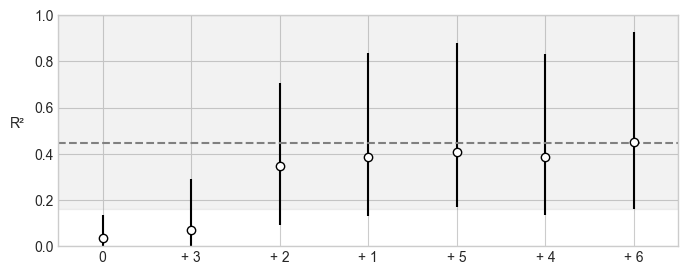

In [10]:
vi_results = pmb.compute_variable_importance(idata, mu, X_test_bart)
pmb.plot_variable_importance(vi_results)

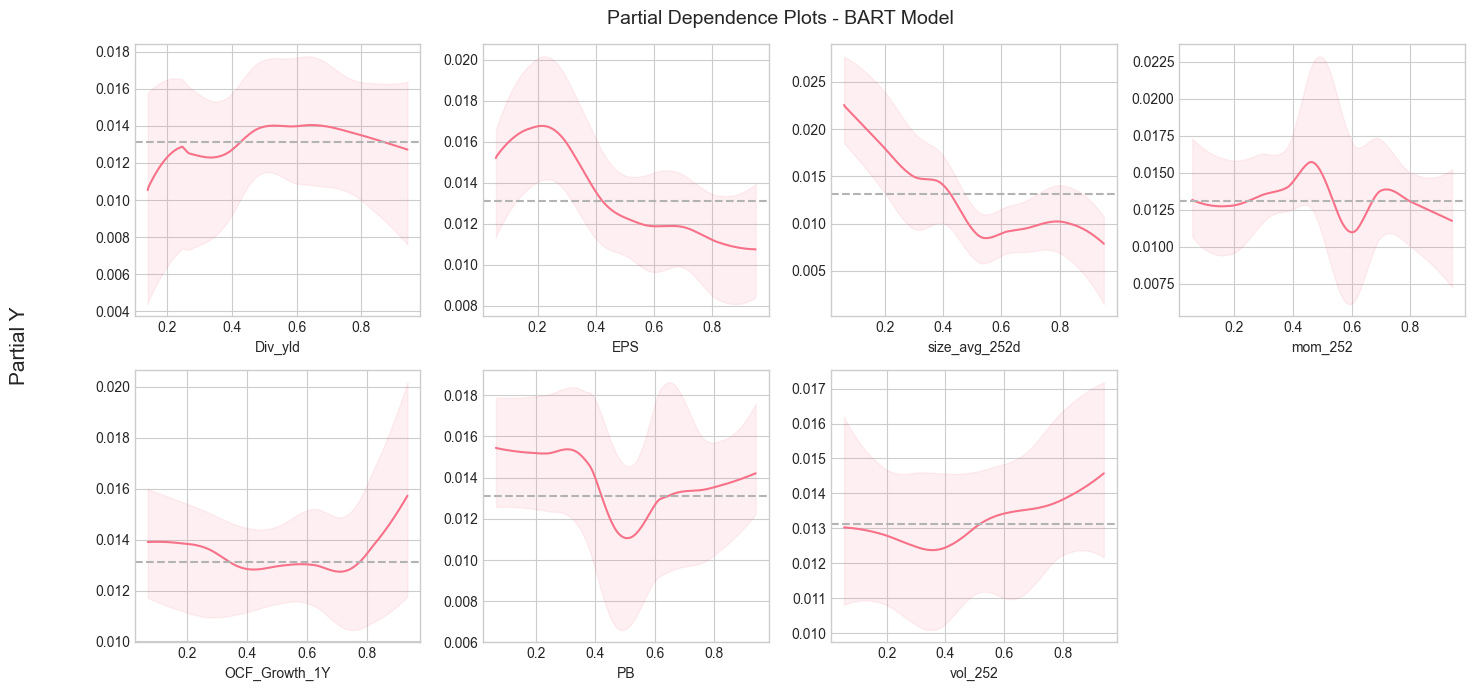

In [11]:
from pymc_bart.utils import plot_pdp                                                              
                                                                                                    
fig, axes = plt.subplots(2, 4, figsize=(14, 7))                                                   
axes = axes.flatten()                                                                             
plot_pdp(bart_model['mu'], X=X_train_bart, Y=y_train_bart,                                        
           xs_interval='quantiles', grid=(2, 4), var_idx=list(range(len(features_short))),          
           var_discrete=None, func=None, samples=100, ax=axes[:len(features_short)])                
for i, feat in enumerate(features_short):                                                         
      axes[i].set_xlabel(feat)                                                                      
axes[-1].axis('off')  # Hide empty subplot                                                        
fig.suptitle('Partial Dependence Plots - BART Model', fontsize=14)                                
plt.tight_layout()                                                                                
plt.show()                                                                                     

And we see that... 

Individual Conditional Expectation (ICE) plots:                                                

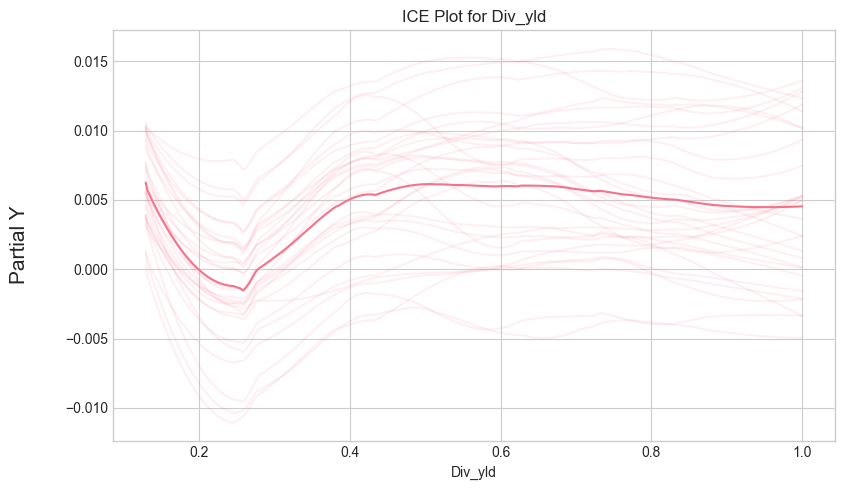

In [12]:
from pymc_bart.utils import plot_ice                                                              
                                                                                                    
fig, ax = plt.subplots(figsize=(8, 5))                                                            
plot_ice(bart_model['mu'], X=X_train_bart, Y=y_train_bart,                                        
           var_idx=[0], centered=True, samples=50, ax=ax)                                           
ax.set_xlabel(features_short[0])                                                                  
ax.set_title(f'ICE Plot for {features_short[0]}')                                                 
plt.tight_layout()                                                                                
plt.show()                                                                                        
                                                                                                    
